In [1]:
# Import the dependencies 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('../data/bank_cleaned.csv')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,prev_contacted
0,58,management,married,tertiary,no,2143,yes,no,missing,5,may,261,1,-1,0,missing,no,0
1,44,technician,single,secondary,no,29,yes,no,missing,5,may,151,1,-1,0,missing,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,missing,5,may,76,1,-1,0,missing,no,0
3,35,management,married,tertiary,no,231,yes,no,missing,5,may,139,1,-1,0,missing,no,0
4,28,management,single,tertiary,no,447,yes,yes,missing,5,may,217,1,-1,0,missing,no,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43190 entries, 0 to 43189
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             43190 non-null  int64
 1   job             43190 non-null  str  
 2   marital         43190 non-null  str  
 3   education       43190 non-null  str  
 4   default         43190 non-null  str  
 5   balance         43190 non-null  int64
 6   housing         43190 non-null  str  
 7   loan            43190 non-null  str  
 8   contact         43190 non-null  str  
 9   day             43190 non-null  int64
 10  month           43190 non-null  str  
 11  duration        43190 non-null  int64
 12  campaign        43190 non-null  int64
 13  pdays           43190 non-null  int64
 14  previous        43190 non-null  int64
 15  poutcome        43190 non-null  str  
 16  y               43190 non-null  str  
 17  prev_contacted  43190 non-null  int64
dtypes: int64(8), str(10)
memory usage: 8.

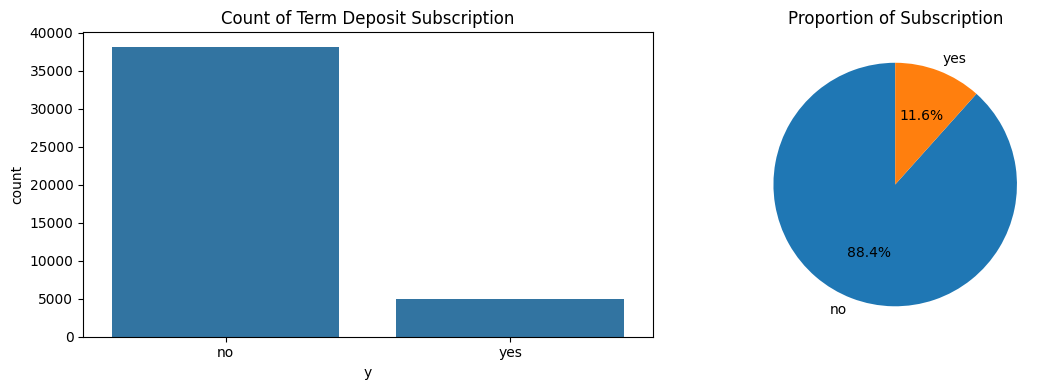

In [4]:
# Plot target balance 
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.countplot(x = 'y', data = df, ax = axes[0])
axes[0].set_title('Count of Term Deposit Subscription')

df['y'].value_counts().plot.pie(autopct = '%1.1f%%', startangle = 90, ax = axes[1])
axes[1].set_ylabel('')
axes[1].set_title('Proportion of Subscription')

plt.tight_layout()
plt.show()

/tmp/ipykernel_64461/544042049.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include = ['object', 'category']).columns


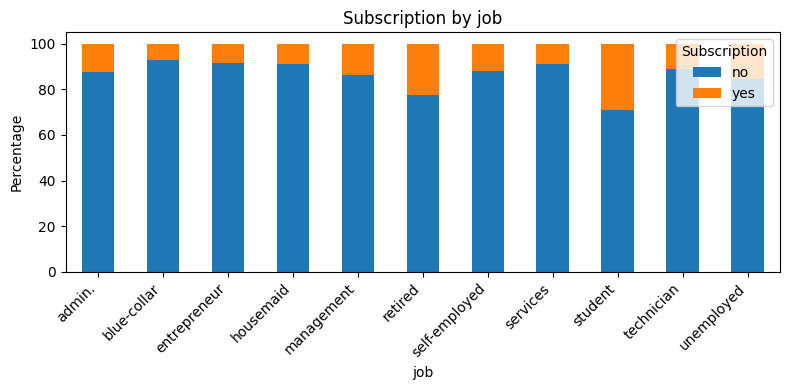

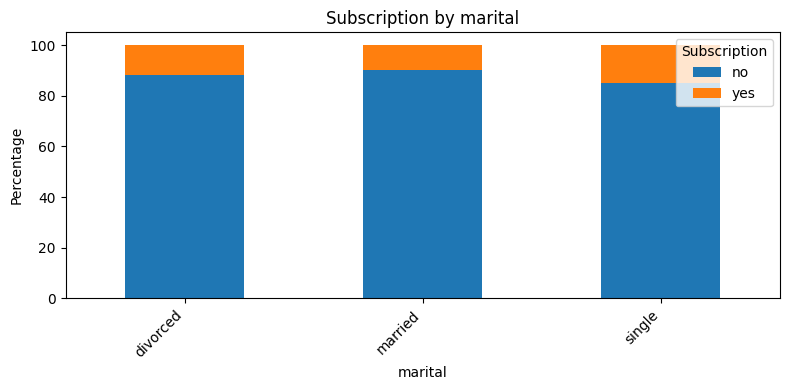

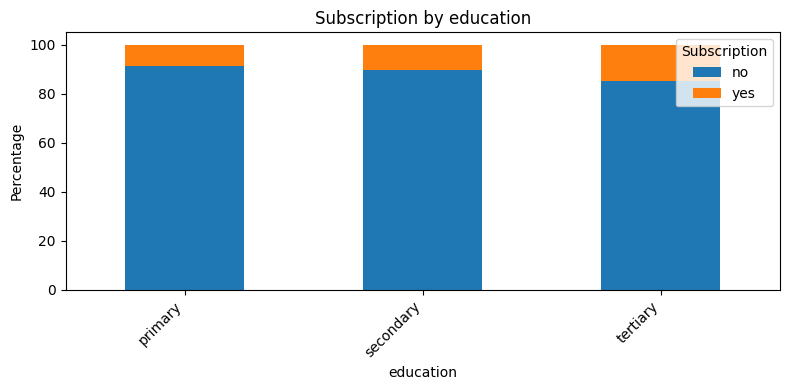

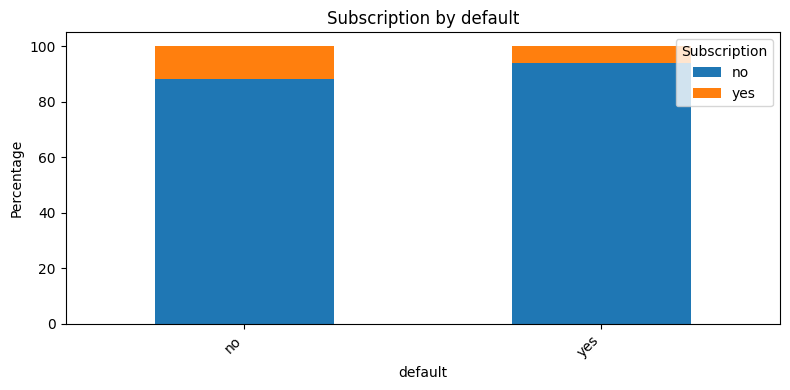

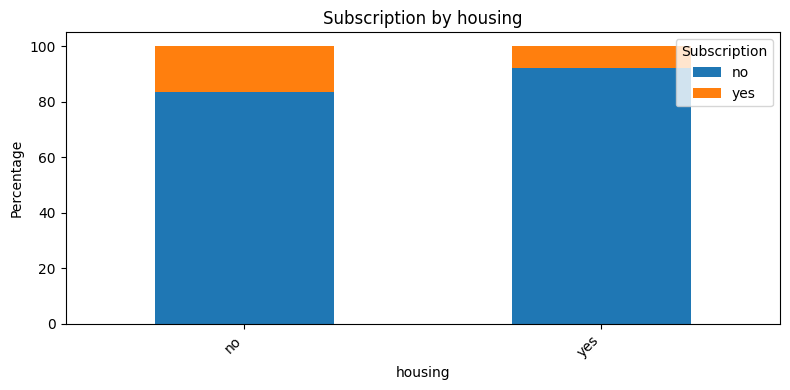

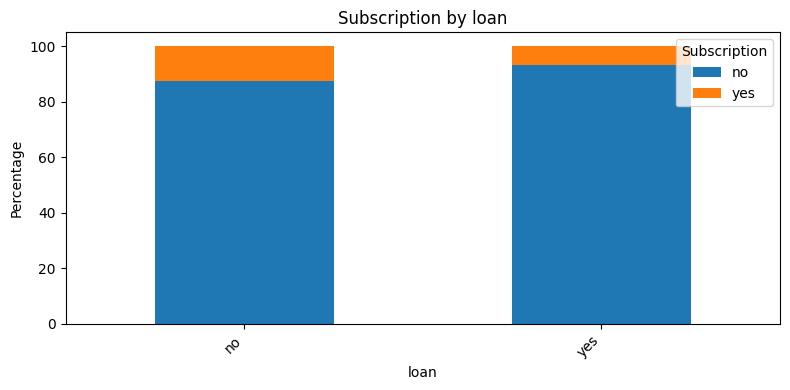

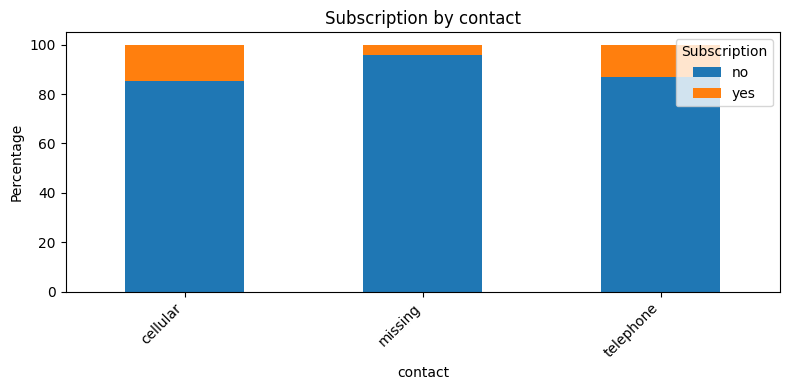

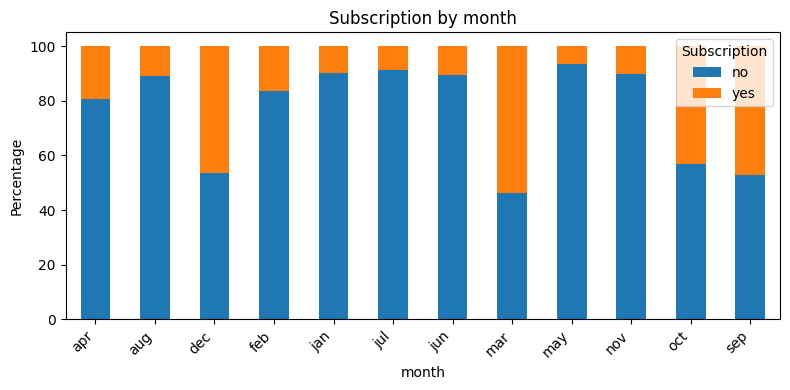

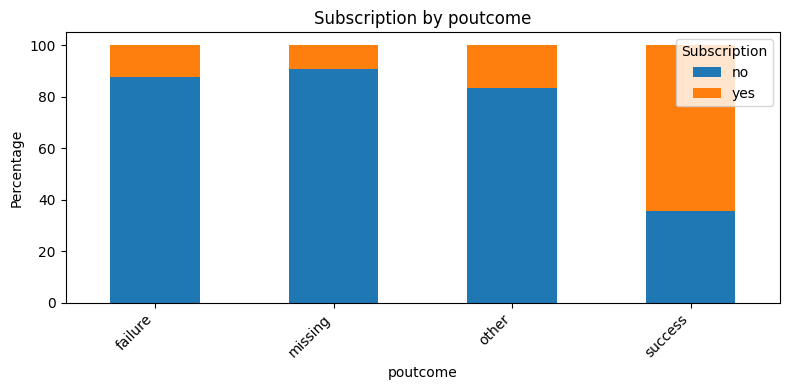

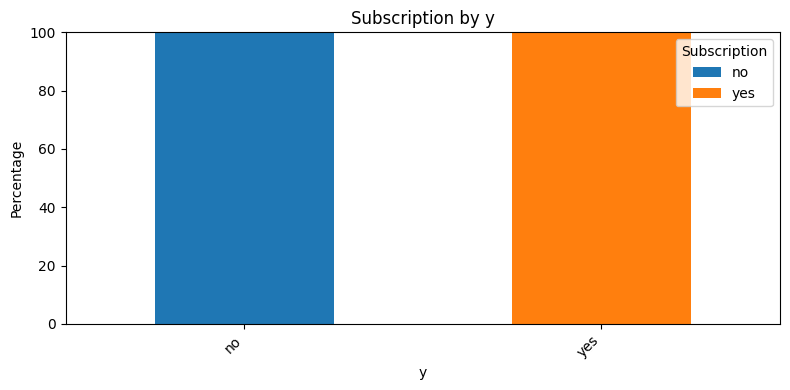

In [5]:
# Create cat_cols
cat_cols = df.select_dtypes(include = ['object', 'category']).columns

# Plot them against target
for col in cat_cols:
    ct = pd.crosstab(df[col], df['y'], normalize = 'index') * 100
    ct.plot(kind = 'bar', stacked = True, figsize = (8, 4))
    
    plt.title(f'Subscription by {col}')
    plt.ylabel('Percentage')
    plt.legend(title = 'Subscription', loc = 'upper right')
    plt.xticks(rotation = 45, ha = 'right')
    plt.tight_layout()
    plt.show()

In [6]:
# Numerical features vs target
num_cols = df.select_dtypes(include = 'int64').columns

df.groupby('y')[num_cols].describe().T

y                               no          yes
age            count  38169.000000  5021.000000
               mean      40.669758    41.481777
               std       10.083268    13.311751
               min       18.000000    18.000000
               25%       33.000000    31.000000
...                            ...          ...
prev_contacted min        0.000000     0.000000
               25%        0.000000     0.000000
               50%        0.000000     0.000000
               75%        0.000000     1.000000
               max        1.000000     1.000000

[64 rows x 2 columns]

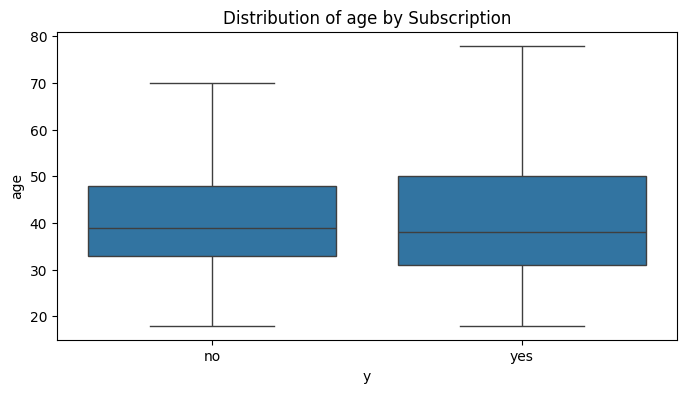

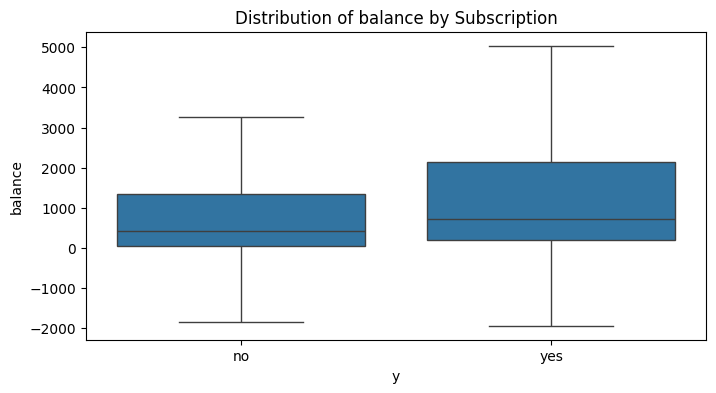

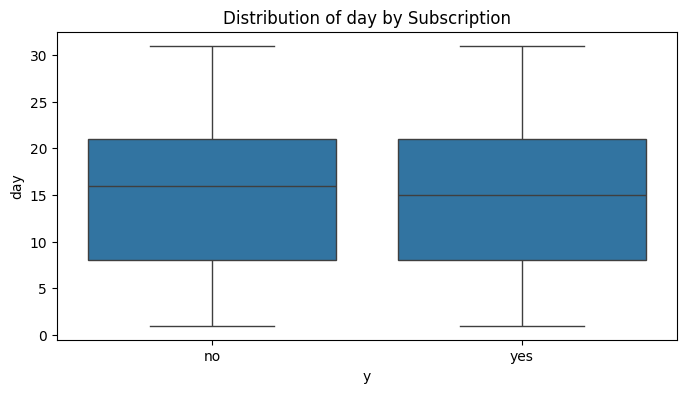

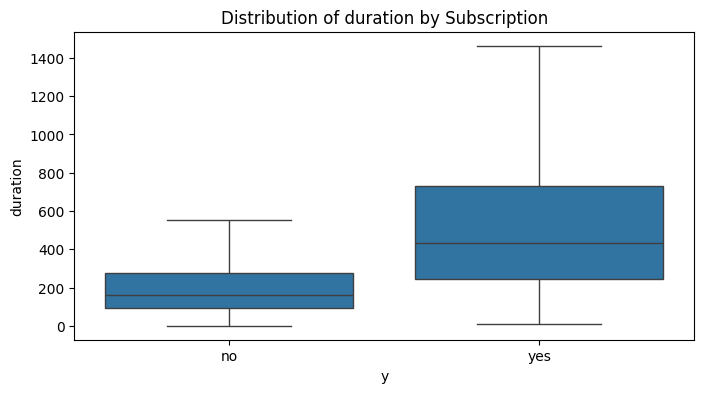

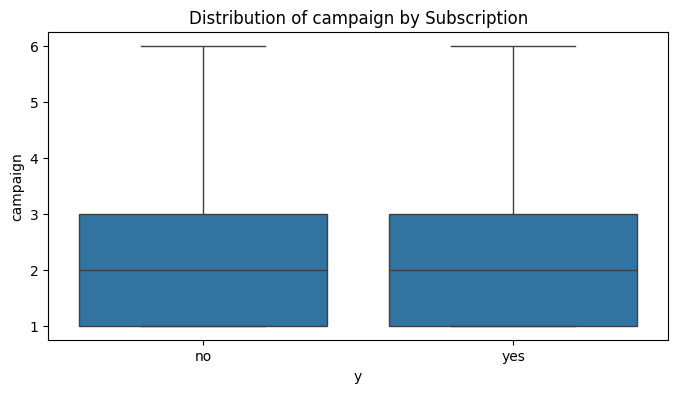

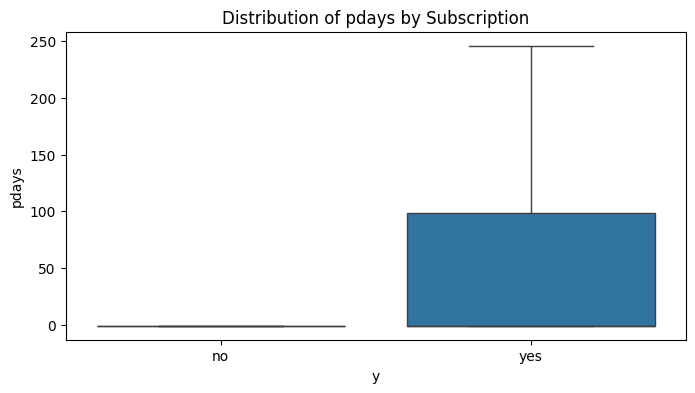

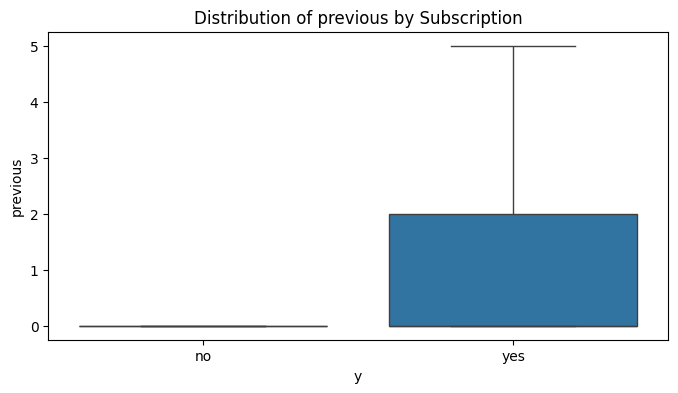

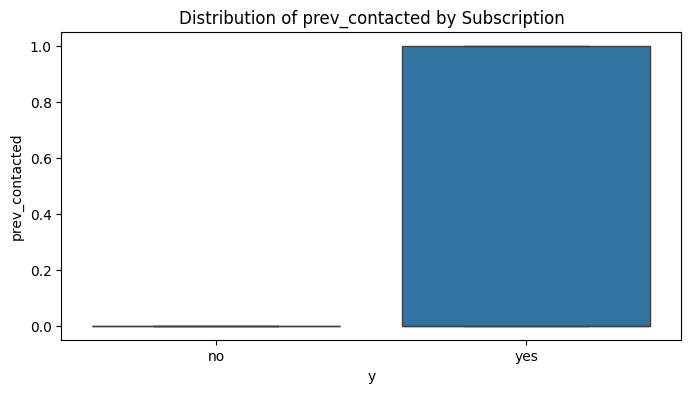

In [7]:
# Boxplot for numerical values
for col in num_cols:
    plt.figure(figsize = (8, 4))

    sns.boxplot(x = 'y', y = col, data = df, showfliers = False)

    plt.title(f'Distribution of {col} by Subscription')
    plt.show()

In [8]:
# Correlation heatmap for pairwise correlation, first encode the target
df['y_binary'] = df['y'].map({'no': 0, 'yes': 1}) 

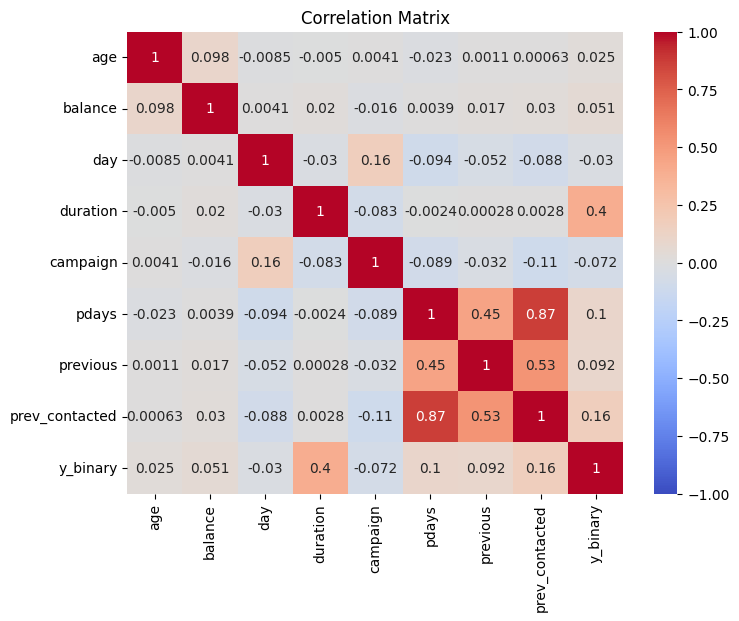

In [9]:
# Corr
corr = df[['age', 'balance', 'day','duration', 'campaign', 'pdays', 'previous', 'prev_contacted', 'y_binary']].corr()

plt.figure(figsize = (8, 6))

sns.heatmap(corr, annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1)

plt.title('Correlation Matrix')
plt.show()

Duration has the highest corr

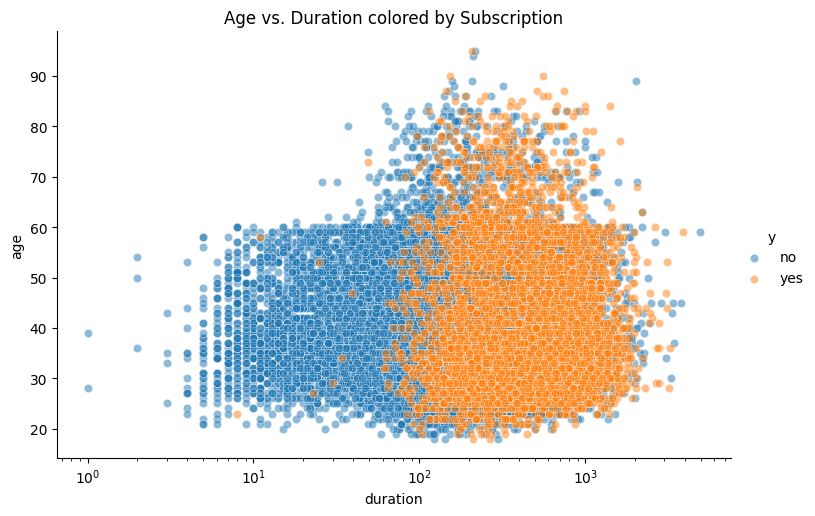

In [10]:
# Duration with age
g = sns.FacetGrid(df, hue = 'y', height = 5, aspect = 1.5)
g.map(sns.scatterplot, 'duration', 'age', alpha = 0.5)
g.add_legend()
plt.xscale('log')
plt.title('Age vs. Duration colored by Subscription')
plt.show()